In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data=pd.read_csv("drug_side_effects_100k_dataset.csv")
print(data)

      patient_id  age  gender   country     drug_name  dosage_mg  \
0      PT-100000   56  Female       USA  Atorvastatin         25   
1      PT-100001   45    Male       USA    Sertraline          5   
2      PT-100002   76  Female  Pakistan       Insulin         25   
3      PT-100003   61  Female       USA   Paracetamol         20   
4      PT-100004   39  Female     India    Amlodipine          5   
...          ...  ...     ...       ...           ...        ...   
99995  PT-199995   42  Female     India   Amoxicillin         10   
99996  PT-199996   55    Male        UK  Atorvastatin         25   
99997  PT-199997   18  Female   Germany   Paracetamol         20   
99998  PT-199998   18    Male    Canada  Atorvastatin         10   
99999  PT-199999   73    Male   Germany     Metformin         50   

          side_effect  severity       outcome report_date  \
0         Muscle Pain  Moderate    Recovering  2021-12-08   
1           Dry Mouth      Mild     Recovered  2023-02-10   


Shape

In [4]:
data.shape

(100000, 16)

Columns

In [5]:
data.columns

Index(['patient_id', 'age', 'gender', 'country', 'drug_name', 'dosage_mg',
       'side_effect', 'severity', 'outcome', 'report_date',
       'treatment_start_date', 'chronic_condition', 'smoker', 'alcohol_use',
       'hospitalized', 'recovery_days'],
      dtype='str')

Stastistics

In [6]:
data.describe()

,age,dosage_mg,recovery_days
count,100000.000000,100000.000000,88262.000000
mean,47.781740,119.896250,23.569996
std,17.055106,162.249791,12.690178
min,18.000000,5.000000,2.000000
25%,35.000000,10.000000,13.000000
50%,47.000000,25.000000,24.000000
75%,60.000000,250.000000,35.000000
max,90.000000,500.000000,45.000000


Data Types

In [7]:
data.dtypes

patient_id                  str
age                       int64
gender                      str
country                     str
drug_name                   str
dosage_mg                 int64
side_effect                 str
severity                    str
outcome                     str
report_date                 str
treatment_start_date        str
chronic_condition           str
smoker                      str
alcohol_use                 str
hospitalized                str
recovery_days           float64
dtype: object

NULL Values

In [8]:
data.isnull().sum()

patient_id                  0
age                         0
gender                      0
country                     0
drug_name                   0
dosage_mg                   0
side_effect                 0
severity                    0
outcome                     0
report_date                 0
treatment_start_date        0
chronic_condition       16743
smoker                      0
alcohol_use             33365
hospitalized                0
recovery_days           11738
dtype: int64

Null Value Percentage

In [9]:
(data.isnull().sum())/len(data)*100

patient_id               0.000
age                      0.000
gender                   0.000
country                  0.000
drug_name                0.000
dosage_mg                0.000
side_effect              0.000
severity                 0.000
outcome                  0.000
report_date              0.000
treatment_start_date     0.000
chronic_condition       16.743
smoker                   0.000
alcohol_use             33.365
hospitalized             0.000
recovery_days           11.738
dtype: float64

Duplicate Values

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data["report_date"]=pd.to_datetime(data["report_date"])
data["treatment_start_date"]=pd.to_datetime(data["treatment_start_date"])

AGE DATA


Patient Data

In [12]:
data["patient_id"].size

100000

Male vs Female Count

In [13]:
data["gender"].value_counts()

gender
Male      50059
Female    49941
Name: count, dtype: int64

Average Age

In [14]:
avg_age=data["age"].mean()
print(avg_age)

47.78174


Min Age

In [15]:
min_age=data["age"].min()
print(min_age)

18


Max Age

In [16]:
max_age=data["age"].max()
print(max_age)

90


Patients  By Country

In [17]:
data.groupby("country")["gender"].value_counts()

country    gender
Australia  Male      7120
           Female    7068
Canada     Female    7151
           Male      7058
Germany    Male      7163
           Female    7139
India      Male      7187
           Female    7153
Pakistan   Female    7114
           Male      7105
UK         Male      7331
           Female    7120
USA        Female    7196
           Male      7095
Name: count, dtype: int64

Smoker Vs Non-Smoker

In [18]:
data["smoker"].value_counts().sort_index()

smoker
No     50242
Yes    49758
Name: count, dtype: int64

Alcoholic vs Non-Alcoholic

In [19]:
data["alcohol_use"].value_counts().sort_index()

alcohol_use
Frequent      33378
Occasional    33257
Name: count, dtype: int64

Chronic Patient


In [20]:
data["chronic_condition"].value_counts().sort_index()

chronic_condition
Asthma            16627
Diabetes          16549
Heart Disease     16620
Hypertension      16548
Kidney Disease    16913
Name: count, dtype: int64

Drug Analysis

Unique Drugs

In [21]:
data["drug_name"].unique()

<StringArray>
['Atorvastatin',   'Sertraline',      'Insulin',  'Paracetamol',
   'Amlodipine',  'Amoxicillin',    'Ibuprofen',    'Metformin',
   'Lisinopril',   'Omeprazole']
Length: 10, dtype: str

Top 10 Used Drugs

In [22]:
data["drug_name"].value_counts().head(10)

drug_name
Amoxicillin     10148
Metformin       10078
Atorvastatin    10035
Amlodipine      10020
Sertraline      10018
Ibuprofen       10015
Omeprazole       9975
Paracetamol      9957
Insulin          9940
Lisinopril       9814
Name: count, dtype: int64

Least Used Drug

In [23]:
data["drug_name"].min()

'Amlodipine'

Average Drug Dose

In [24]:
data["dosage_mg"].mean()

np.float64(119.89625)

Highest Dosage

In [25]:
high_dose=data["dosage_mg"].max()
print(high_dose)

500


Drug Distribution Chart

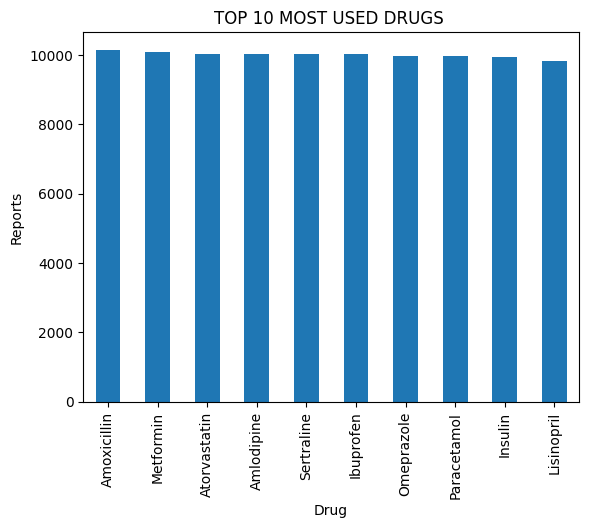

In [26]:
data["drug_name"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Drug")
plt.ylabel("Reports")
plt.xticks(rotation=90)
plt.title("TOP 10 MOST USED DRUGS ")
plt.show()

Side Effect Analysis

Most Common Side Effects

In [27]:
data["side_effect"].value_counts()

side_effect
Nausea            13373
Fatigue            9911
Rash               6755
Diarrhea           6685
Dizziness          6679
Headache           6654
Abdominal Pain     3414
Muscle Pain        3358
Sweating           3358
Insomnia           3352
Stomach Pain       3348
Constipation       3343
Swelling           3340
Anxiety            3337
Dry Mouth          3329
Weight Gain        3329
Heartburn          3319
Liver Toxicity     3304
Palpitations       3284
Dry Cough          3275
Hypoglycemia       3253
Name: count, dtype: int64

Unique Side Effects

In [28]:
unique_sideEffects=data["side_effect"].unique()
print(unique_sideEffects)

<StringArray>
[   'Muscle Pain',      'Dry Mouth',   'Hypoglycemia',           'Rash',
      'Dizziness',         'Nausea',       'Sweating',       'Swelling',
        'Anxiety',   'Stomach Pain', 'Abdominal Pain',       'Headache',
        'Fatigue',    'Weight Gain',      'Heartburn',       'Diarrhea',
      'Dry Cough',   'Constipation', 'Liver Toxicity',   'Palpitations',
       'Insomnia']
Length: 21, dtype: str


Number of unique side Effects

In [29]:
data["side_effect"].nunique()

21

Top 10 Side  Effects

In [30]:
top=data["side_effect"].value_counts().head(10)
print(top)

side_effect
Nausea            13373
Fatigue            9911
Rash               6755
Diarrhea           6685
Dizziness          6679
Headache           6654
Abdominal Pain     3414
Muscle Pain        3358
Sweating           3358
Insomnia           3352
Name: count, dtype: int64


Most side Effects Drug

In [31]:
data.groupby(["side_effect","drug_name"]).size().sort_values().head(1)

side_effect   drug_name
Hypoglycemia  Insulin      3253
dtype: int64

Side Effect By Gender

In [32]:
data.groupby("side_effect")["gender"].value_counts()

side_effect     gender
Abdominal Pain  Male      1734
                Female    1680
Anxiety         Male      1703
                Female    1634
Constipation    Female    1682
                Male      1661
Diarrhea        Female    3344
                Male      3341
Dizziness       Male      3375
                Female    3304
Dry Cough       Male      1642
                Female    1633
Dry Mouth       Female    1683
                Male      1646
Fatigue         Female    5051
                Male      4860
Headache        Female    3355
                Male      3299
Heartburn       Female    1704
                Male      1615
Hypoglycemia    Male      1634
                Female    1619
Insomnia        Male      1722
                Female    1630
Liver Toxicity  Male      1690
                Female    1614
Muscle Pain     Female    1683
                Male      1675
Nausea          Male      6731
                Female    6642
Palpitations    Male      1645
                

Side Effect by Age roup

In [33]:
data["AgeGroup"] = pd.cut(
    data["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)
data["AgeGroup"]

0         Adult
1         Adult
2        Senior
3        Senior
4         Adult
          ...  
99995     Adult
99996     Adult
99997      Teen
99998      Teen
99999    Senior
Name: AgeGroup, Length: 100000, dtype: category
Categories (5, str): ['Child' < 'Teen' < 'Young Adult' < 'Adult' < 'Senior']

In [34]:
result = data.groupby("side_effect")["AgeGroup"].value_counts()

print(result)

side_effect     AgeGroup   
Abdominal Pain  Adult          1740
                Senior          807
                Young Adult     685
                Teen            182
                Child             0
                               ... 
Weight Gain     Adult          1730
                Senior          745
                Young Adult     671
                Teen            183
                Child             0
Name: count, Length: 105, dtype: int64




Severity Analysis

Severity Distribution

In [35]:
data["severity"].value_counts()

severity
Mild        61969
Moderate    29926
Severe       8105
Name: count, dtype: int64


Mild Percentage 

In [36]:
(data["severity"] == "Mild").mean() * 100

np.float64(61.968999999999994)

Moderate Percentage 

In [37]:
(data["severity"] == "Moderate").mean() * 100

np.float64(29.926000000000002)

Severe Percentage 

In [38]:
(data["severity"] == "Severe").mean() * 100

np.float64(8.105)

Drug With Severe Reactions

In [39]:
data.groupby(["side_effect","severity"]).size().sort_values().head(10)

side_effect     severity
Dry Cough       Severe      229
Palpitations    Severe      242
Swelling        Severe      250
Dry Mouth       Severe      254
Hypoglycemia    Severe      256
Constipation    Severe      257
Abdominal Pain  Severe      260
Sweating        Severe      263
Stomach Pain    Severe      268
Liver Toxicity  Severe      274
dtype: int64

Severity By Gender

In [40]:
data.groupby(["gender","severity"]).size().head(10)

gender  severity
Female  Mild        30940
        Moderate    14952
        Severe       4049
Male    Mild        31029
        Moderate    14974
        Severe       4056
dtype: int64

Severity by Age Group

In [41]:
data.groupby(["AgeGroup","severity"]).size().head(10)

AgeGroup     severity
Teen         Mild         3391
             Moderate     1604
             Severe        422
Young Adult  Mild        12272
             Moderate     5985
             Severe       1636
Adult        Mild        31582
             Moderate    15409
             Severe       4162
Senior       Mild        14724
dtype: int64

Severity by Smoker

In [42]:
data.groupby(["smoker","severity"]).size().head(10)

smoker  severity
No      Mild        31150
        Moderate    15025
        Severe       4067
Yes     Mild        30819
        Moderate    14901
        Severe       4038
dtype: int64

Severity by Alcoholic Group


In [43]:
data.groupby(["alcohol_use","severity"]).size().head(10)

alcohol_use  severity
Frequent     Mild        20676
             Moderate    10017
             Severe       2685
Occasional   Mild        20536
             Moderate     9984
             Severe       2737
dtype: int64

Severity by Chronic Condition

In [44]:
data.groupby(["chronic_condition","severity"]).size().head(10)

chronic_condition  severity
Asthma             Mild        10333
                   Moderate     4924
                   Severe       1370
Diabetes           Mild        10310
                   Moderate     4905
                   Severe       1334
Heart Disease      Mild        10344
                   Moderate     4958
                   Severe       1318
Hypertension       Mild        10182
dtype: int64

Severe Cases by Drug

In [45]:
data[data["severity"]=="Severe"].value_counts().head(10)

patient_id  age  gender  country    drug_name    dosage_mg  side_effect     severity  outcome     report_date  treatment_start_date  chronic_condition  smoker  alcohol_use  hospitalized  recovery_days  AgeGroup   
PT-100043   53   Female  Australia  Lisinopril   5          Dry Cough       Severe    Recovering  2022-06-29   2022-06-17            Kidney Disease     No      Occasional   No            44.0           Adult          1
PT-100051   56   Female  Canada     Lisinopril   250        Dry Cough       Severe    Recovered   2024-10-25   2024-09-11            Kidney Disease     Yes     Frequent     No            38.0           Adult          1
PT-100109   25   Female  Germany    Paracetamol  5          Liver Toxicity  Severe    Recovering  2023-06-14   2023-05-24            Kidney Disease     No      Frequent     No            26.0           Young Adult    1
PT-100139   33   Female  USA        Metformin    250        Diarrhea        Severe    Recovering  2026-03-17   2026-02-01        

Severity Percentage

In [46]:
data["severity"].value_counts(normalize=True)*100

severity
Mild        61.969
Moderate    29.926
Severe       8.105
Name: proportion, dtype: float64

OUTCOME ANALYSIS

Outcome Distribution

In [47]:
data["outcome"].value_counts()

outcome
Recovered       69165
Recovering      19097
Hospitalized    10314
Fatal            1424
Name: count, dtype: int64

Most Common OutCome

In [48]:
data["outcome"].mode()

0    Recovered
Name: outcome, dtype: str

Recovery Rate

In [49]:
(data["outcome"]=="Recovered").mean()*100

np.float64(69.16499999999999)

Hospitalization Rate

In [50]:
(data["outcome"]=="Hospitalized").mean()*100

np.float64(10.314)

Average recovery Days

In [51]:
data["recovery_days"].mean()

np.float64(23.56999614783259)

Average Recovery Days by Outcome

In [52]:
data.groupby("outcome")["recovery_days"].mean().sort_values()

outcome
Recovered       23.541835
Recovering      23.671990
Fatal                 NaN
Hospitalized          NaN
Name: recovery_days, dtype: float64

Longest Recovery Time

In [53]:
data["recovery_days"].max()

np.float64(45.0)

Shortest Recovery Time

In [54]:

data["recovery_days"].min()

np.float64(2.0)

Recovery Days by Severity

In [55]:
data.groupby("severity")["recovery_days"].mean()

severity
Mild        23.555949
Moderate    23.631522
Severe      23.399725
Name: recovery_days, dtype: float64

Recovery Days by Drug


In [56]:
data.groupby("drug_name")["recovery_days"].mean()

drug_name
Amlodipine      23.530621
Amoxicillin     23.631073
Atorvastatin    23.478251
Ibuprofen       23.615995
Insulin         23.285016
Lisinopril      23.844109
Metformin       23.535726
Omeprazole      23.563605
Paracetamol     23.559357
Sertraline      23.661617
Name: recovery_days, dtype: float64

Outcome vs Severity

In [57]:
data.groupby(["severity","outcome"]).size()

severity  outcome     
Mild      Hospitalized     1262
          Recovered       54555
          Recovering       6152
Moderate  Fatal             603
          Hospitalized     5403
          Recovered       13415
          Recovering      10505
Severe    Fatal             821
          Hospitalized     3649
          Recovered        1195
          Recovering       2440
dtype: int64

Date Analysis

Convert Date Column

In [58]:
data["treatment_start_date"]=pd.to_datetime(data["treatment_start_date"])
data["report_date"]=pd.to_datetime(data["report_date"])

Report By Year

In [59]:
data["report_date"].dt.year.value_counts().sort_index()

report_date
2021    10682
2022    19977
2023    20027
2024    20039
2025    19932
2026     9343
Name: count, dtype: int64

Reports By Month

In [60]:
data["report_date"].dt.month.value_counts().sort_index()

report_date
1     8462
2     7833
3     8468
4     8218
5     8541
6     8307
7     8524
8     8484
9     8221
10    8364
11    8191
12    8387
Name: count, dtype: int64

Most Reporting Month

In [61]:
data["report_date"].dt.month.max()


np.int32(12)

Treatment Duration

In [62]:
data["treatment_duration"]=data["report_date"]-data["treatment_start_date"]
data["treatment_duration"]

0       15 days
1        6 days
2       29 days
3       14 days
4       47 days
          ...  
99995   17 days
99996   45 days
99997    5 days
99998   47 days
99999   55 days
Name: treatment_duration, Length: 100000, dtype: timedelta64[us]

Average Treatment Duration

In [63]:
data["treatment_duration"].mean()

Timedelta('30 days 11:16:59.232000')

VISUALIZATION

Gender Distribution

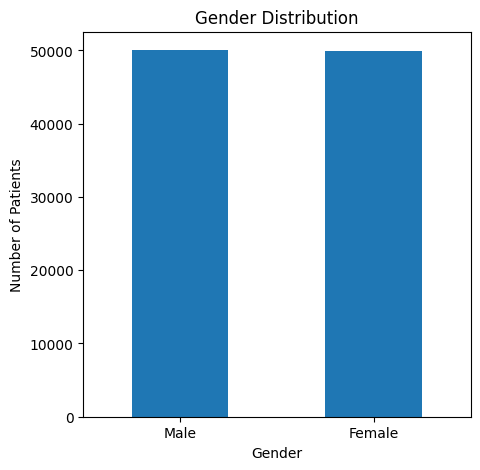

In [64]:
plt.figure(figsize=(5,5))
data["gender"].value_counts().plot(kind="bar")


plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.title("Gender Distribution")
plt.xticks(rotation=0)

plt.show()

Age Distribution Histogram

Text(0, 0.5, 'Number of Patients')

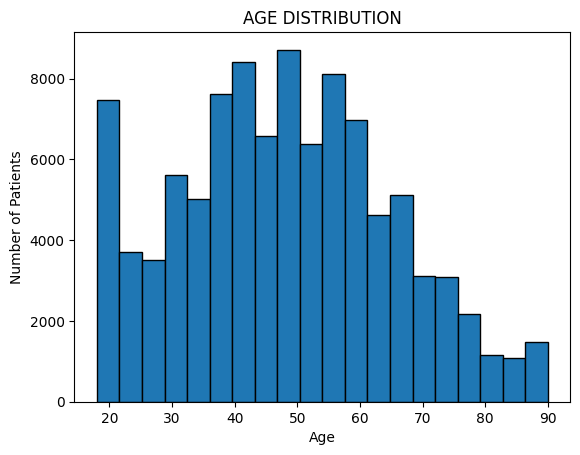

In [65]:
plt.hist(data["age"],bins=20,edgecolor="black")

plt.title("AGE DISTRIBUTION")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

Top 10 Drugs

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Amoxicillin'),
  Text(1, 0, 'Metformin'),
  Text(2, 0, 'Atorvastatin'),
  Text(3, 0, 'Amlodipine'),
  Text(4, 0, 'Sertraline'),
  Text(5, 0, 'Ibuprofen'),
  Text(6, 0, 'Omeprazole'),
  Text(7, 0, 'Paracetamol'),
  Text(8, 0, 'Insulin'),
  Text(9, 0, 'Lisinopril')])

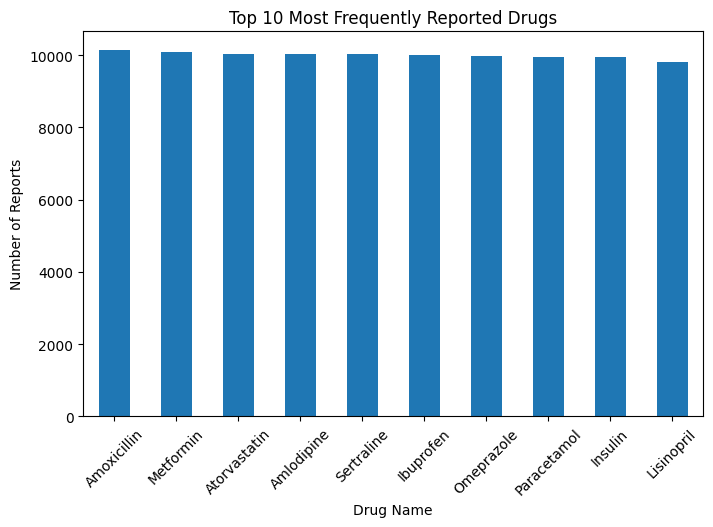

In [66]:
plt.figure(figsize=(8,5))
data["drug_name"].value_counts().plot(kind="bar")
plt.title("Top 10 Most Frequently Reported Drugs")
plt.xlabel("Drug Name")
plt.ylabel("Number of Reports")
plt.xticks(rotation=45)

Top 10 Side Effects

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 [Text(0, 0, 'Nausea'),
  Text(1, 0, 'Fatigue'),
  Text(2, 0, 'Rash'),
  Text(3, 0, 'Diarrhea'),
  Text(4, 0, 'Dizziness'),
  Text(5, 0, 'Headache'),
  Text(6, 0, 'Abdominal Pain'),
  Text(7, 0, 'Muscle Pain'),
  Text(8, 0, 'Sweating'),
  Text(9, 0, 'Insomnia'),
  Text(10, 0, 'Stomach Pain'),
  Text(11, 0, 'Constipation'),
  Text(12, 0, 'Swelling'),
  Text(13, 0, 'Anxiety'),
  Text(14, 0, 'Dry Mouth'),
  Text(15, 0, 'Weight Gain'),
  Text(16, 0, 'Heartburn'),
  Text(17, 0, 'Liver Toxicity'),
  Text(18, 0, 'Palpitations'),
  Text(19, 0, 'Dry Cough'),
  Text(20, 0, 'Hypoglycemia')])

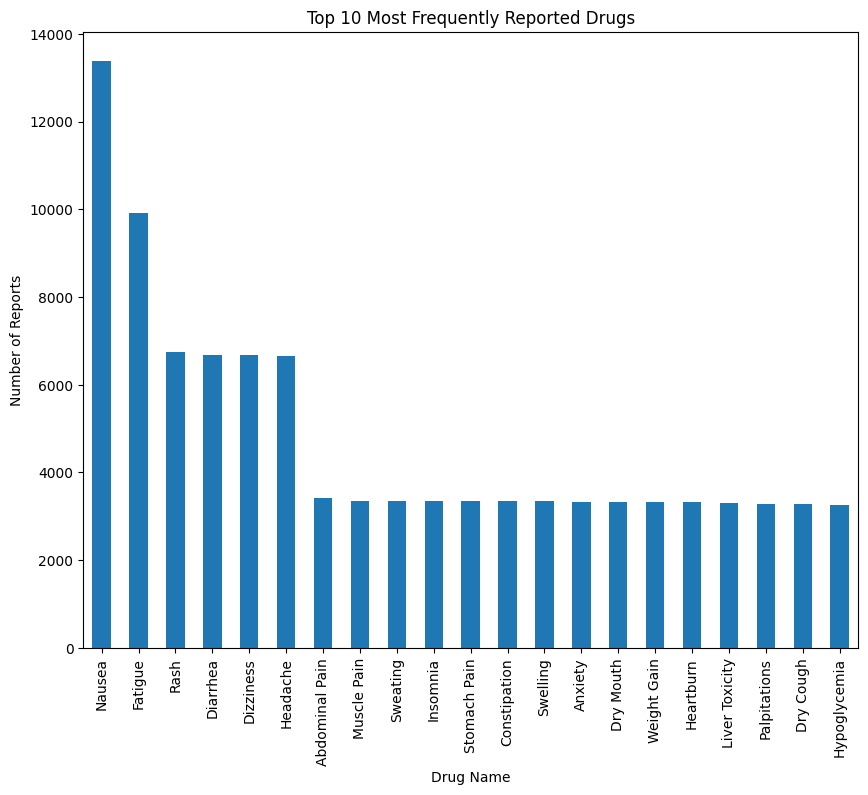

In [67]:
plt.figure(figsize=(10,8))
data["side_effect"].value_counts().plot(kind="bar")
plt.title("Top 10 Most Frequently Reported Drugs")
plt.xlabel("Drug Name")
plt.ylabel("Number of Reports")
plt.xticks(rotation=90)

Severity Distribution

Text(0, 0.5, 'Number of Cases')

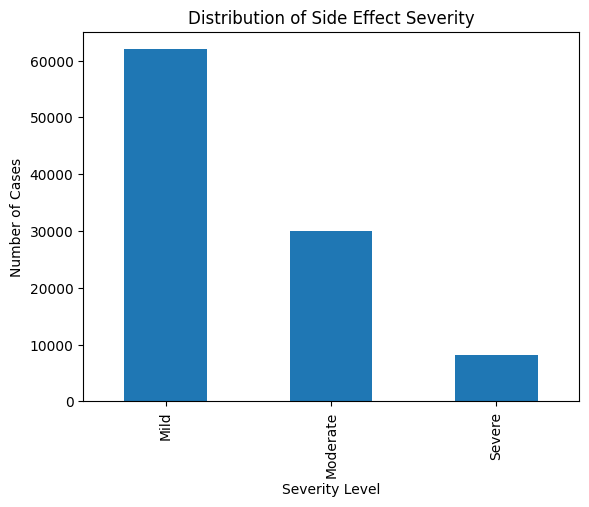

In [68]:
data["severity"].value_counts().plot(kind="bar")
plt.title("Distribution of Side Effect Severity")
plt.xlabel("Severity Level")
plt.ylabel("Number of Cases")

Outcome Distribution

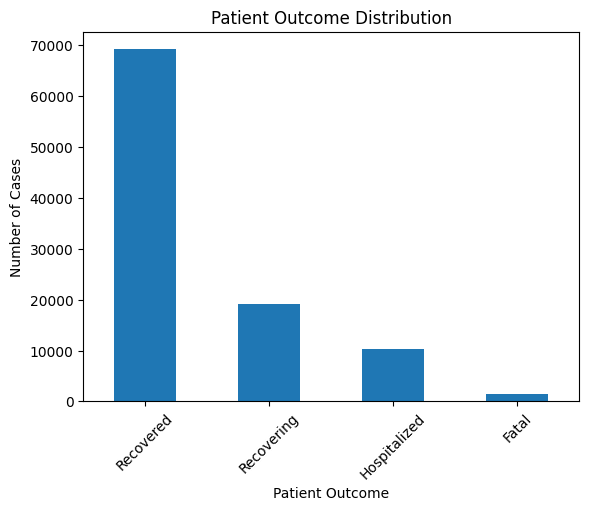

In [69]:
data["outcome"].value_counts().plot(kind="bar")

plt.xlabel("Patient Outcome")
plt.ylabel("Number of Cases")
plt.title("Patient Outcome Distribution")

plt.xticks(rotation=45)
plt.show()

Smoke Vs Severity

Text(0, 0.5, 'Number of Cases')

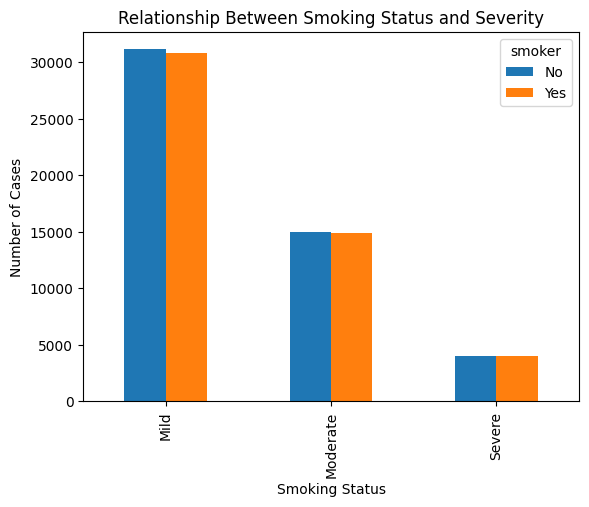

In [70]:
severe=data.groupby(["severity","smoker"]).size().unstack()
severe.plot(kind="bar")
plt.title("Relationship Between Smoking Status and Severity")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Cases")

Alcohol Vs Severity

Text(0, 0.5, 'Number of Cases')

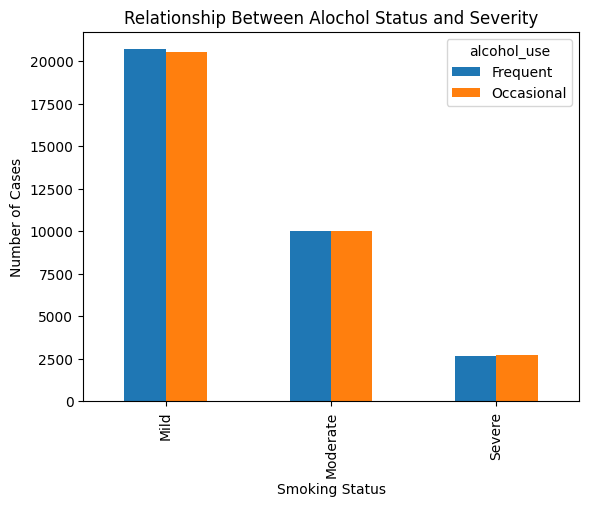

In [71]:
severe=data.groupby(["severity","alcohol_use"]).size().unstack()
severe.plot(kind="bar")
plt.title("Relationship Between Alochol Status and Severity")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Cases")

Text(0, 0.5, 'Number of Patients')

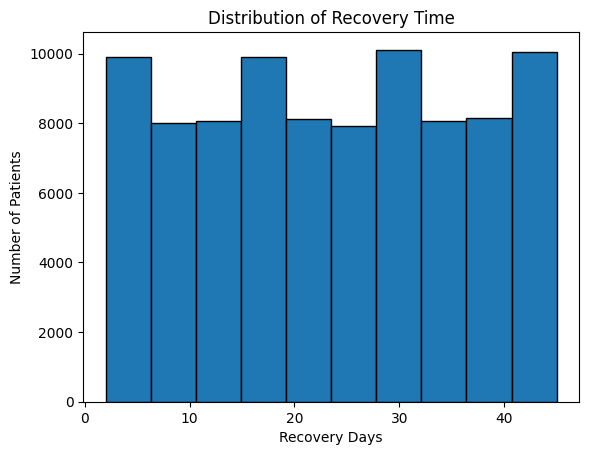

In [72]:
plt.hist(data["recovery_days"],bins=10,edgecolor="black")
plt.title("Distribution of Recovery Time")
plt.xlabel("Recovery Days")
plt.ylabel("Number of Patients")

Null Confirmation

In [73]:
data.isnull().sum()

patient_id                  0
age                         0
gender                      0
country                     0
drug_name                   0
dosage_mg                   0
side_effect                 0
severity                    0
outcome                     0
report_date                 0
treatment_start_date        0
chronic_condition       16743
smoker                      0
alcohol_use             33365
hospitalized                0
recovery_days           11738
AgeGroup                    0
treatment_duration          0
dtype: int64

FIX Null Values

In [74]:
data["chronic_condition"]=data["chronic_condition"].fillna("Unknown")
data["alcohol_use"]=data["alcohol_use"].fillna("Unknown")


In [80]:
data.isnull().sum()

patient_id              0
age                     0
gender                  0
country                 0
drug_name               0
dosage_mg               0
side_effect             0
severity                0
outcome                 0
report_date             0
treatment_start_date    0
chronic_condition       0
smoker                  0
alcohol_use             0
hospitalized            0
recovery_days           0
AgeGroup                0
treatment_duration      0
dtype: int64

Check Duplicates

In [82]:

data.duplicated().sum()

np.int64(0)

Data Info 

In [83]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype          
---  ------                --------------   -----          
 0   patient_id            100000 non-null  str            
 1   age                   100000 non-null  int64          
 2   gender                100000 non-null  str            
 3   country               100000 non-null  str            
 4   drug_name             100000 non-null  str            
 5   dosage_mg             100000 non-null  int64          
 6   side_effect           100000 non-null  str            
 7   severity              100000 non-null  str            
 8   outcome               100000 non-null  str            
 9   report_date           100000 non-null  datetime64[us] 
 10  treatment_start_date  100000 non-null  datetime64[us] 
 11  chronic_condition     100000 non-null  str            
 12  smoker                100000 non-null  str            
 

Category Consistency

In [85]:
for col in ["gender","severity","outcome","smoker","alcohol_use"]:
    print(col)
    print(data[col].unique())

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
severity
<StringArray>
['Moderate', 'Mild', 'Severe']
Length: 3, dtype: str
outcome
<StringArray>
['Recovering', 'Recovered', 'Hospitalized', 'Fatal']
Length: 4, dtype: str
smoker
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
alcohol_use
<StringArray>
['Frequent', 'Unknown', 'Occasional']
Length: 3, dtype: str
